In [1]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cartopy.crs as ccrs


from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [177]:
fp = '/data/jmex/NOAA//latest/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25), time = slice(None,None))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15))


In [178]:
#interpolate to tp grid
sst = sst.interp(lat = tp.lat, lon = tp.lon, method = 'nearest')
#make new ocean mask to subselect tp field
ocean_mask2 = ~sst.isel(time = 1).sst.isnull()

#subselect tp field
tp = tp.where(ocean_mask2)

In [179]:
tp = tp.where(tp.time.dt.month.isin([8,9,10])).groupby('time.year').mean()
tp = tp.weighted(np.cos(np.deg2rad(tp.lat))).mean('lat')

In [180]:
#compute anomaly
clim = tp.sel(year = slice('1991', '2020')).mean('year')
tp = tp-clim

In [199]:
#compute variablity
q10tp = tp.quantile(0.1, dim = 'year')
q90tp = tp.quantile(0.9, dim = 'year') 

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1389: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


## Make composite event


In [200]:
cyears =  [1982, 1987, 1991, 1997, 2015]

In [201]:
cmtp = tp.where(tp.year.isin(cyears), drop = True).mean('year')


In [202]:
cstdtp = tp.where(tp.year.isin(cyears), drop = True).std('year')

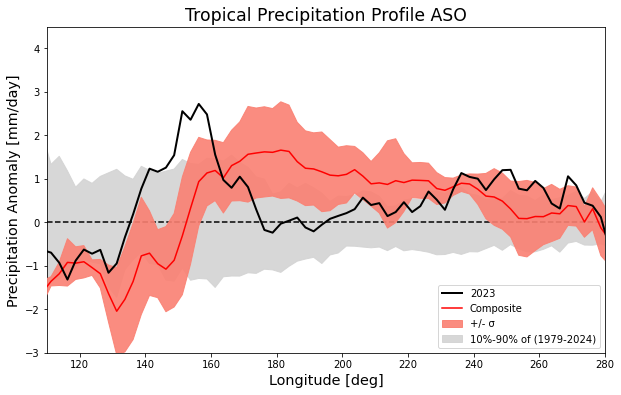

In [204]:
fig, ax = plt.subplots(figsize = (10,6))
#plot variabliity nino
ax.fill_between(cstdtp.lon, (cmtp+cstdtp).tp, (cmtp-cstdtp).tp,
                color = 'salmon', alpha = 0.9, label = '+/- σ', zorder = 10)



#all variability
ax.fill_between(q10tp.lon, q10tp.tp, q90tp.tp,
                color = 'lightgrey', alpha = 0.9, label = '10%-90% of (1979-2024)')



tp.sel(year = 2023).tp.plot(ax = ax, c = 'k', linewidth = 2, label = '2023', zorder= 15)

cmtp.tp.plot(c = 'red', label = 'Composite', zorder = 12)



# Customize the plot
ax.set_ylim(-3,4.5)
ax.set_xlim(110,280) 
ax.axhline(0, c = 'k', linestyle = '--')

ax.set_title('Tropical Precipitation Profile ASO', fontweight = 'normal')
ax.set_xlabel('Longitude [deg]', fontweight = 'normal')
ax.set_ylabel('Precipitation Anomaly [mm/day]',fontweight = 'normal')
ax.legend(loc = 'lower right')




In [236]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15))


sst = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()
sst = sst.weighted(np.cos(np.deg2rad(sst.lat))).mean('lat')

In [237]:
rawsst = sst.copy()

In [238]:
#compute anomaly
clim = sst.sel(year = slice('1991', '2020')).mean('year')
sst = sst-clim

In [255]:
c_rawsst = rawsst.where(rawsst.year.isin(cyears), drop = True).mean('year')

In [239]:
#compute variablity
q10 = sst.quantile(0.1, dim = 'year')
q90 = sst.quantile(0.9, dim = 'year') 

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1389: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


## Make composite event


In [241]:
cyears =  [1982, 1987, 1991, 1997, 2015]

In [242]:
cm = sst.where(sst.year.isin(cyears), drop = True).mean('year')


In [243]:
cstd = sst.where(sst.year.isin(cyears), drop = True).std('year')

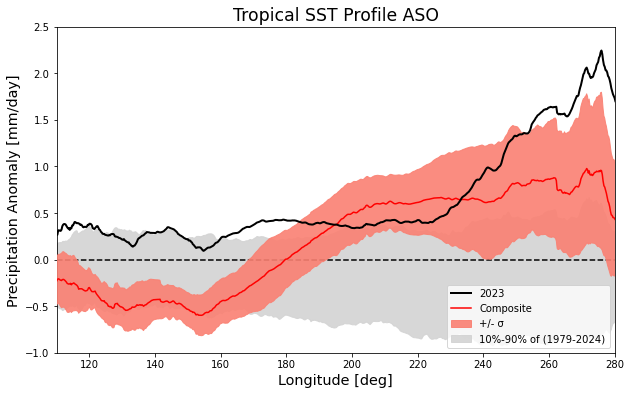

In [252]:
fig, ax = plt.subplots(figsize = (10,6))
#plot variabliity nino
ax.fill_between(cstd.lon, (cm+cstd).sst, (cm-cstd).sst,
                color = 'salmon', alpha = 0.9, label = '+/- σ', zorder = 10)



#all variability
ax.fill_between(q10.lon, q10.sst, q90.sst,
                color = 'lightgrey', alpha = 0.9, label = '10%-90% of (1979-2024)')



sst.sel(year = 2023).sst.plot(ax = ax, c = 'k', linewidth = 2, label = '2023', zorder= 15)

cm.sst.plot(c = 'red', label = 'Composite', zorder = 12)



# Customize the plot
ax.set_ylim(-1,2.5)
ax.set_xlim(110,280) 
ax.axhline(0, c = 'k', linestyle = '--')

ax.set_title('Tropical SST Profile ASO', fontweight = 'normal')
ax.set_xlabel('Longitude [deg]', fontweight = 'normal')
ax.set_ylabel('Precipitation Anomaly [mm/day]',fontweight = 'normal')
ax.legend(loc = 'lower right')




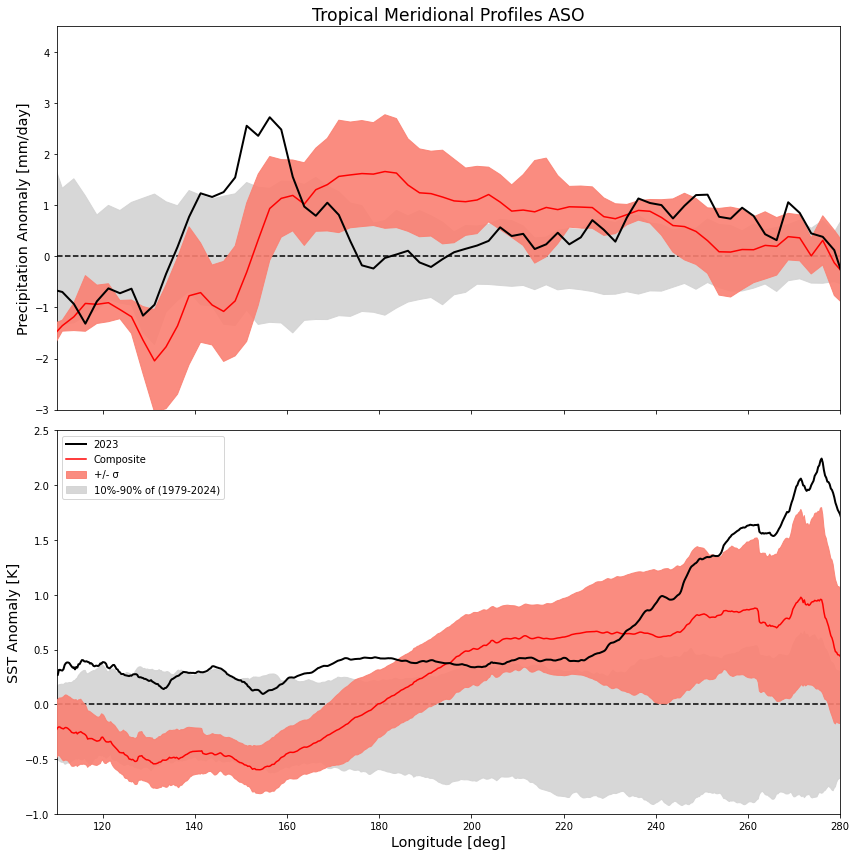

In [259]:
fig, axs = plt.subplots(2,1 , sharex = True, figsize = (12,12))


ax = axs[0]
#plot variabliity nino
ax.fill_between(cstdtp.lon, (cmtp+cstdtp).tp, (cmtp-cstdtp).tp,
                color = 'salmon', alpha = 0.9, label = '+/- σ', zorder = 10)



#all variability
ax.fill_between(q10tp.lon, q10tp.tp, q90tp.tp,
                color = 'lightgrey', alpha = 0.9, label = '10%-90% of (1979-2024)')



tp.sel(year = 2023).tp.plot(ax = ax, c = 'k', linewidth = 2, label = '2023', zorder= 15)

cmtp.tp.plot(c = 'red', label = 'Composite', zorder = 12,ax = ax)



# Customize the plot
ax.set_ylim(-3,4.5)
ax.axhline(0, c = 'k', linestyle = '--')
ax.set_xlabel('')
ax.set_title('Tropical Meridional Profiles ASO', fontweight = 'normal')
ax.set_ylabel('Precipitation Anomaly [mm/day]',fontweight = 'normal')


#plot variabliity nino
axs[1].fill_between(cstd.lon, (cm+cstd).sst, (cm-cstd).sst,
                color = 'salmon', alpha = 0.9, label = '+/- σ', zorder = 10)



#all variability
axs[1].fill_between(q10.lon, q10.sst, q90.sst,
                color = 'lightgrey', alpha = 0.9, label = '10%-90% of (1979-2024)')



sst.sel(year = 2023).sst.plot(ax = axs[1], c = 'k', linewidth = 2, label = '2023', zorder= 15)

cm.sst.plot(c = 'red', label = 'Composite', zorder = 12)

"""ax2 = axs[1].twinx()
rawsst.sel(year = 2023).sst.plot(ax = ax2, c = 'k', linestyle = '--')
c_rawsst.sst.plot(ax = ax2, c = 'r', linestyle = '--')

ax2.set_ylim(299.5, 303)
"""

# Customize the plot
axs[1].set_ylim(-1,2.5)
axs[1].set_xlim(110,280) 
axs[1].axhline(0, c = 'k', linestyle = '--')

axs[1].set_xlabel('Longitude [deg]', fontweight = 'normal')
axs[1].set_ylabel('SST Anomaly [K]',fontweight = 'normal')
axs[1].legend(loc = 'upper left')

plt.tight_layout()

